# 07. Model Training - Pandas

## 07.1. Importação das bibliotecas

### 07.1.1. Importando as bibliotecas nativas do Python

In [1]:
import sys
import warnings

### 07.1.2. Importando as bibliotecas de terceiros

In [2]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import GridSearchCV, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, PowerTransformer
from sklearn.tree import DecisionTreeRegressor

### 07.1.3. Importando os módulos locais do projeto

In [3]:
sys.path.append('..')
import functions.fn_charts_pandas as fn_charts_pandas
import functions.fn_stats_pandas as fn_stats_pandas
import params.consts as consts

## 07.2. Visão geral dos dados

### 07.2.1. Habilitando a exibição de todas as colunas e linhas

In [4]:
pd.set_option('display.max_columns', None); pd.set_option('display.max_rows', None)

### 07.2.2. Armazenando o dataset em uma variável

In [5]:
df = pd.read_parquet(consts.DATASET_CLEAN_PANDAS)

### 07.2.3. Visualizando a quantidade de linhas e colunas do dataset

In [6]:
df.shape

(581983, 19)

### 07.2.4. Exibindo o dataset

In [7]:
df.head(5)

,host_is_superhost,host_listings_count,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,bed_type,price,extra_people,minimum_nights,instant_bookable,is_business_travel_ready,cancellation_policy,ano,mes
0,t,2.0,-22.965919,-43.178962,Condominium,Entire home/apt,5,1,2,2,Real Bed,270.0,51.0,4,t,f,strict,2018,4
1,f,3.0,-22.977117,-43.190454,Apartment,Entire home/apt,3,1,1,2,Real Bed,161.0,45.0,4,f,f,strict,2018,4
2,t,1.0,-22.983024,-43.214270,Apartment,Entire home/apt,3,1,1,2,Real Bed,222.0,68.0,2,t,f,strict,2018,4
3,t,1.0,-22.988165,-43.193588,Apartment,Entire home/apt,3,1,1,2,Real Bed,308.0,86.0,2,f,f,strict,2018,4
4,t,1.0,-22.981269,-43.190457,Loft,Entire home/apt,2,1,1,2,Real Bed,219.0,80.0,3,t,f,strict,2018,4


### 07.2.5. Visualizando os detalhes do dataset

In [8]:
df.info(verbose = True, show_counts = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581983 entries, 0 to 581982
Data columns (total 19 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   host_is_superhost         581983 non-null  object 
 1   host_listings_count       581983 non-null  float64
 2   latitude                  581983 non-null  float64
 3   longitude                 581983 non-null  float64
 4   property_type             581983 non-null  object 
 5   room_type                 581983 non-null  object 
 6   accommodates              581983 non-null  int64  
 7   bathrooms                 581983 non-null  int64  
 8   bedrooms                  581983 non-null  int64  
 9   beds                      581983 non-null  int64  
 10  bed_type                  581983 non-null  object 
 11  price                     581983 non-null  float64
 12  extra_people              581983 non-null  float64
 13  minimum_nights            581983 non-null  i

### 07.2.6. Visualizando as estatísticas das colunas numéricas

In [9]:
fn_stats_pandas.describe(df)

,host_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,extra_people,minimum_nights,ano,mes
count,581983.00,581983.00,581983.00,581983.00,581983.00,581983.00,581983.00,581983.00,581983.00,581983.00,581983.00,581983.00
mean,1.71,-22.96,-43.25,3.47,1.36,1.36,2.10,319.63,22.38,2.55,2018.85,6.34
std,1.22,0.04,0.10,1.63,0.58,0.73,1.23,262.00,33.89,1.64,0.72,3.40
min,0.00,-23.07,-43.72,1.00,0.00,0.00,0.00,0.00,0.00,1.00,2018.00,1.00
25%,1.00,-22.98,-43.30,2.00,1.00,1.00,1.00,138.00,0.00,1.00,2018.00,4.00
50%,1.00,-22.97,-43.20,3.00,1.00,1.00,2.00,228.00,0.00,2.00,2019.00,6.00
75%,2.00,-22.94,-43.19,4.00,2.00,2.00,3.00,401.00,50.00,3.00,2019.00,9.00
max,6.00,-22.75,-43.10,9.00,3.00,3.00,6.00,1276.00,125.00,8.00,2020.00,12.00


### 07.2.7. Visualizando as estatísticas da colunas categóricas

In [10]:
df.describe(exclude = 'number')

,host_is_superhost,property_type,room_type,bed_type,instant_bookable,is_business_travel_ready,cancellation_policy
count,581983,581983,581983,581983,581983,581983,581983
unique,2,12,4,2,2,1,4
top,f,Apartment,Entire home/apt,Real Bed,f,f,flexible
freq,519412,458354,372443,570643,352395,581983,258096


### 07.2.8. Verificando os valores nulos das colunas

In [11]:
df.isnull().sum()

host_is_superhost           0
host_listings_count         0
latitude                    0
longitude                   0
property_type               0
room_type                   0
accommodates                0
bathrooms                   0
bedrooms                    0
beds                        0
bed_type                    0
price                       0
extra_people                0
minimum_nights              0
instant_bookable            0
is_business_travel_ready    0
cancellation_policy         0
ano                         0
mes                         0
dtype: int64

### 07.2.9. Verificando os valores distintos das colunas

In [12]:
df.nunique()

host_is_superhost               2
host_listings_count             7
latitude                    47567
longitude                   50975
property_type                  12
room_type                       4
accommodates                    9
bathrooms                       4
bedrooms                        4
beds                            7
bed_type                        2
price                        1248
extra_people                  115
minimum_nights                  8
instant_bookable                2
is_business_travel_ready        1
cancellation_policy             4
ano                             3
mes                            12
dtype: int64

### 07.2.10. Verificando os registos totalmente duplicados

In [13]:
len(df) - len(df.drop_duplicates())

26

### 07.2.11. Verificando a quantidade de colunas numéricas, categóricas e de data

In [14]:
num_cols = df.select_dtypes(include = 'number').shape[1]

categ_cols = df.select_dtypes(include = 'object').shape[1]

date_cols = df.select_dtypes(include = ['datetime64[ns]', 'datetime64[ns, UTC]']).shape[1]

print(f'- Numeric Columns: {num_cols}\n- Categoric Columns: {categ_cols}\n- Date Columns: {date_cols}')

- Numeric Columns: 12
- Categoric Columns: 7
- Date Columns: 0


## 07.3. Treinamento do modelo de classificação

### 07.3.1. Definindo os valores de X e y

In [15]:
X = df.drop('price', axis = 1)

X.head(5)

,host_is_superhost,host_listings_count,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,bed_type,extra_people,minimum_nights,instant_bookable,is_business_travel_ready,cancellation_policy,ano,mes
0,t,2.0,-22.965919,-43.178962,Condominium,Entire home/apt,5,1,2,2,Real Bed,51.0,4,t,f,strict,2018,4
1,f,3.0,-22.977117,-43.190454,Apartment,Entire home/apt,3,1,1,2,Real Bed,45.0,4,f,f,strict,2018,4
2,t,1.0,-22.983024,-43.214270,Apartment,Entire home/apt,3,1,1,2,Real Bed,68.0,2,t,f,strict,2018,4
3,t,1.0,-22.988165,-43.193588,Apartment,Entire home/apt,3,1,1,2,Real Bed,86.0,2,f,f,strict,2018,4
4,t,1.0,-22.981269,-43.190457,Loft,Entire home/apt,2,1,1,2,Real Bed,80.0,3,t,f,strict,2018,4


In [16]:
y = df['price']

y.head(5)

0    270.0
1    161.0
2    222.0
3    308.0
4    219.0
Name: price, dtype: float64

### 07.3.2. Listando as colunas numéricas e categóricas

In [17]:
numerical_features = X.select_dtypes(include = 'number').columns

print('Numerical Features:')

for i in numerical_features:

    print(f'- {i}')

Numerical Features:
- host_listings_count
- latitude
- longitude
- accommodates
- bathrooms
- bedrooms
- beds
- extra_people
- minimum_nights
- ano
- mes


In [18]:
categorical_features = X.select_dtypes(exclude = 'number').columns

print('\nCategorical Features:')

for i in categorical_features:
    
    print(f'- {i}')


Categorical Features:
- host_is_superhost
- property_type
- room_type
- bed_type
- instant_bookable
- is_business_travel_ready
- cancellation_policy


### 07.3.3. Criando histogramas para entender a distribuição de dados das colunas

- Gráfico: Histograma.


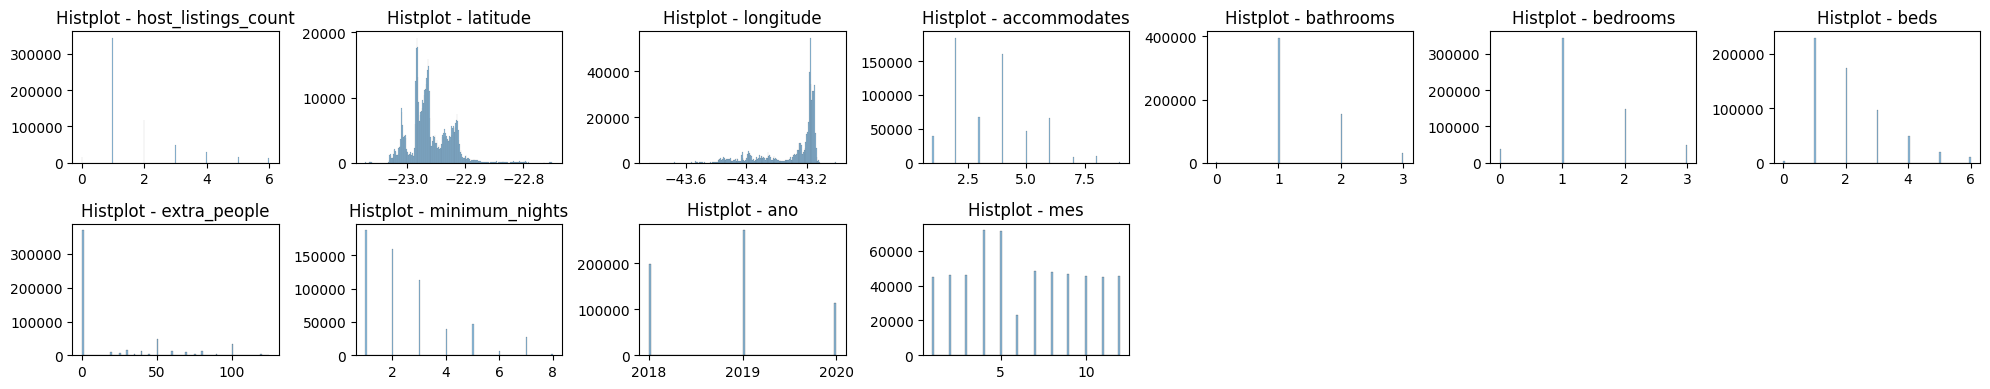

In [19]:
print('- Gráfico: Histograma.')

fn_charts_pandas.histplot(X, numerical_features, num_cols = 7, height_figsize = 2)

plt.savefig(f'../images/outputs/charts/pandas/nb08_histplot.png', format = 'png', dpi = 75, bbox_inches = 'tight', transparent = True)

plt.show()

### 07.3.4. Definindo o pré processamento das colunas de acordo com a distribuição dos seus dados

- **One Hot Encoder:** Indicado para colunas categóricas ou que possuem inteiros discretos.
- **Power Transformer:** Indicado para colunas com assimetria dos dados.
- **Min-Max Scaler:** Indicado para colunas com distribuição uniforme dos dados.

In [20]:
one_hot_encoder_columns = [
    'host_is_superhost',
    'property_type',
    'room_type',
    'bed_type',
    'instant_bookable',
    'is_business_travel_ready',
    'cancellation_policy',
    'host_listings_count',
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'minimum_nights',
]

power_transformer_columns = [
   'extra_people',
   'latitude',
   'longitude',
]

min_max_scaler_columns = [
    'ano',
    'mes',
]

### 07.3.5. Definindo os pré processamentos que serão aplicados nas colunas

In [21]:
pre_processing = ColumnTransformer([

    ('one_hot_encoder_columns', OneHotEncoder(), one_hot_encoder_columns),

    ('power_transformer_columns', PowerTransformer(), power_transformer_columns),

    ('min_max_scaler_columns', MinMaxScaler(), min_max_scaler_columns)

])

### 07.3.6. Criando o pipeline inicial

In [22]:
pipeline_initial = Pipeline([
        
    ('pre_processing', pre_processing),

    # ('feature_selection', SelectKBest(score_func = f_regression, k = 10)),
    
    ('models', DecisionTreeRegressor(random_state = consts.RANDOM_STATE)),
    
])

### 07.3.7. Treinando o modelo inicial

In [23]:
pipeline_initial.fit(X, y)

c:\Users\mathe\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:197: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
c:\Users\mathe\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:208: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


Pipeline(steps=[('pre_processing',
                 ColumnTransformer(transformers=[('one_hot_encoder_columns',
                                                  OneHotEncoder(),
                                                  ['host_is_superhost',
                                                   'property_type', 'room_type',
                                                   'bed_type',
                                                   'instant_bookable',
                                                   'is_business_travel_ready',
                                                   'cancellation_policy',
                                                   'host_listings_count',
                                                   'accommodates', 'bathrooms',
                                                   'bedrooms', 'beds',
                                                   'minimum_nights']),
                                                 ('power_transformer_columns',
                                                  PowerTransformer(),
                                                  ['extra_people', 'latitude',
                                                   'longitude']),
                                                 ('min_max_scaler_columns',
                                                  MinMaxScaler(),
                                                  ['ano', 'mes'])])),
                ('models', DecisionTreeRegressor(random_state=42))])

### 07.3.8. Aplicando o pipeline no modelo inicial

In [24]:
scores_initial = cross_validate(

    pipeline_initial,

    X,

    y,

    cv = KFold(n_splits = 2, shuffle = True, random_state = consts.RANDOM_STATE),
    
    scoring = ['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error', 'neg_mean_squared_error'],
    
    n_jobs = -2,

)

## 07.4. Otimização dos hiperparâmetros

### 07.4.1. Definindo o Grid Search

In [25]:
grid_search = GridSearchCV(

    Pipeline([
            
        ('pre_processing', pre_processing),

        ('feature_selection', SelectKBest(score_func = f_regression, k = 10)),
        
        ('models', DecisionTreeRegressor(random_state = consts.RANDOM_STATE)),
        
    ]),
    
    {

        'feature_selection__k': [10, 15, 20],

        # 'models__criterion': ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],

        'models__splitter': ['best', 'random'],
        
        # 'models__min_samples_split': [2, 3],
        
        'models__min_samples_leaf': [1, 2]
        
    },
    
    scoring = ['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error', 'neg_mean_squared_error'],
    
    n_jobs = -2,
    
    refit = 'r2'

)

### 07.4.2. Encontrando a melhor combinação de hiperparâmetros

In [26]:
warnings.filterwarnings('ignore')

grid_search.fit(X, y)

GridSearchCV(estimator=Pipeline(steps=[('pre_processing',
                                        ColumnTransformer(transformers=[('one_hot_encoder_columns',
                                                                         OneHotEncoder(),
                                                                         ['host_is_superhost',
                                                                          'property_type',
                                                                          'room_type',
                                                                          'bed_type',
                                                                          'instant_bookable',
                                                                          'is_business_travel_ready',
                                                                          'cancellation_policy',
                                                                          'host_listings_count',
                                                                          'accommodates',
                                                                          'bathrooms',
                                                                          'bedrooms',
                                                                          'beds',
                                                                          'minimum_nights']),
                                                                        ('po...
                                        SelectKBest(score_func=<function f_regression at 0x00000293A2E082C0>)),
                                       ('models',
                                        DecisionTreeRegressor(random_state=42))]),
             n_jobs=-2,
             param_grid={'feature_selection__k': [10, 15, 20],
                         'models__min_samples_leaf': [1, 2],
                         'models__splitter': ['best', 'random']},
             refit='r2',
             scoring=['r2', 'neg_root_mean_squared_error',
                      'neg_mean_absolute_error', 'neg_mean_squared_error'])

### 07.4.3. Listando os melhores hiperparâmetros

In [27]:
grid_search.best_params_

{'feature_selection__k': 20,
 'models__min_samples_leaf': 1,
 'models__splitter': 'best'}

## 07.5. Treinamento otimizado do modelo de classificação

### 07.5.1. Criando o pipeline final

In [28]:
pipeline_final = Pipeline([

    ('pre_processing', pre_processing),

    ('feature_selection', SelectKBest(score_func = f_regression, k = grid_search.best_params_['feature_selection__k'])),
    
    ('models', DecisionTreeRegressor(

        random_state = consts.RANDOM_STATE,

        # criterion = grid_search.best_params_['models__criterion'],

        splitter = grid_search.best_params_['models__splitter'],

        # min_samples_split = grid_search.best_params_['models__min_samples_split'],

        min_samples_leaf = grid_search.best_params_['models__min_samples_leaf'],

    )),
    
])

### 07.5.2. Treinando o modelo final

In [29]:
pipeline_final.fit(X, y)

Pipeline(steps=[('pre_processing',
                 ColumnTransformer(transformers=[('one_hot_encoder_columns',
                                                  OneHotEncoder(),
                                                  ['host_is_superhost',
                                                   'property_type', 'room_type',
                                                   'bed_type',
                                                   'instant_bookable',
                                                   'is_business_travel_ready',
                                                   'cancellation_policy',
                                                   'host_listings_count',
                                                   'accommodates', 'bathrooms',
                                                   'bedrooms', 'beds',
                                                   'minimum_nights']),
                                                 ('power_transformer_columns',
                                                  PowerTransformer(),
                                                  ['extra_people', 'latitude',
                                                   'longitude']),
                                                 ('min_max_scaler_columns',
                                                  MinMaxScaler(),
                                                  ['ano', 'mes'])])),
                ('feature_selection',
                 SelectKBest(k=20,
                             score_func=<function f_regression at 0x00000293A2E082C0>)),
                ('models', DecisionTreeRegressor(random_state=42))])

### 07.5.3. Aplicando o pipeline no modelo final

In [30]:
scores_final = cross_validate(

    pipeline_final,
    
    X,
    
    y,

    cv = KFold(n_splits = 2, shuffle = True, random_state = consts.RANDOM_STATE),

    scoring = ['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error', 'neg_mean_squared_error'],
    
    n_jobs = -2,

)

### 07.5.4. Evitando overfitting do modelo

- **Feature Selection:** No aspecto de Feature Selection, foi aplicado o SelectKBest para selecionar as melhores features (colunas) para a criação do modelo, de modo que estivessem somente as features mais relevantes para o modelo e que não houvesse dados redundantes.
- **Validação Cruzada:** No aspecto de Validação Cruzada, foi aplicado o K-Fold, para dividir o conjunto de treinamento em várias partes (folds) e realizar o treinamento e validação do modelo em combinações diferentes desses folds, de modo que se obtém resultados mais confiáveis das métricas de avaliação do modelo e reduz o viés associado a uma única divisão do conjunto de treinamento.
- **Otimização de Hiperparâmetros:** No aspecto de Otimização de Hiperparâmetros, foi aplicado o Grid Search para se combinar os melhores parâmetros das etapas do pipeline, de modo que se obtenha os melhores resultados nas métricas de avaliação para ter um modelo com boa performance e evitar o overfitting.

## 07.6. Comparação entre versões

### 07.6.1. Criando um dataset com as métricas iniciais e finais do treinamento do modelo

In [31]:
df_metrics = pd.concat([

    pd.DataFrame(scores_initial).assign(time = lambda df: df['fit_time'] + df['score_time'], results = 'initial'),

    pd.DataFrame(scores_final).assign(time = lambda df: df['fit_time'] + df['score_time'], results = 'final'),
    
], ignore_index = True)

df_metrics = df_metrics.rename(columns = lambda c: c.replace('test_', ''))

df_metrics = df_metrics.drop(columns = ['fit_time', 'score_time'])

df_metrics = df_metrics.reindex(columns = ['results', 'r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error', 'neg_mean_squared_error', 'time'])

df_metrics

,results,r2,neg_root_mean_squared_error,neg_mean_absolute_error,neg_mean_squared_error,time
0,initial,0.920258,-74.047518,-18.962138,-5483.034916,186.675385
1,initial,0.917602,-75.142959,-19.076264,-5646.464264,189.079322
2,final,0.928511,-70.110821,-18.484298,-4915.527269,34.816966
3,final,0.927443,-70.513300,-18.630049,-4972.125414,35.038296


### 07.6.2. Criando diagramas de caixa para comparar as métricas do modelo antes e depois da otimização de hiperparâmetros

- Gráfico: Diagrama de Caixa.


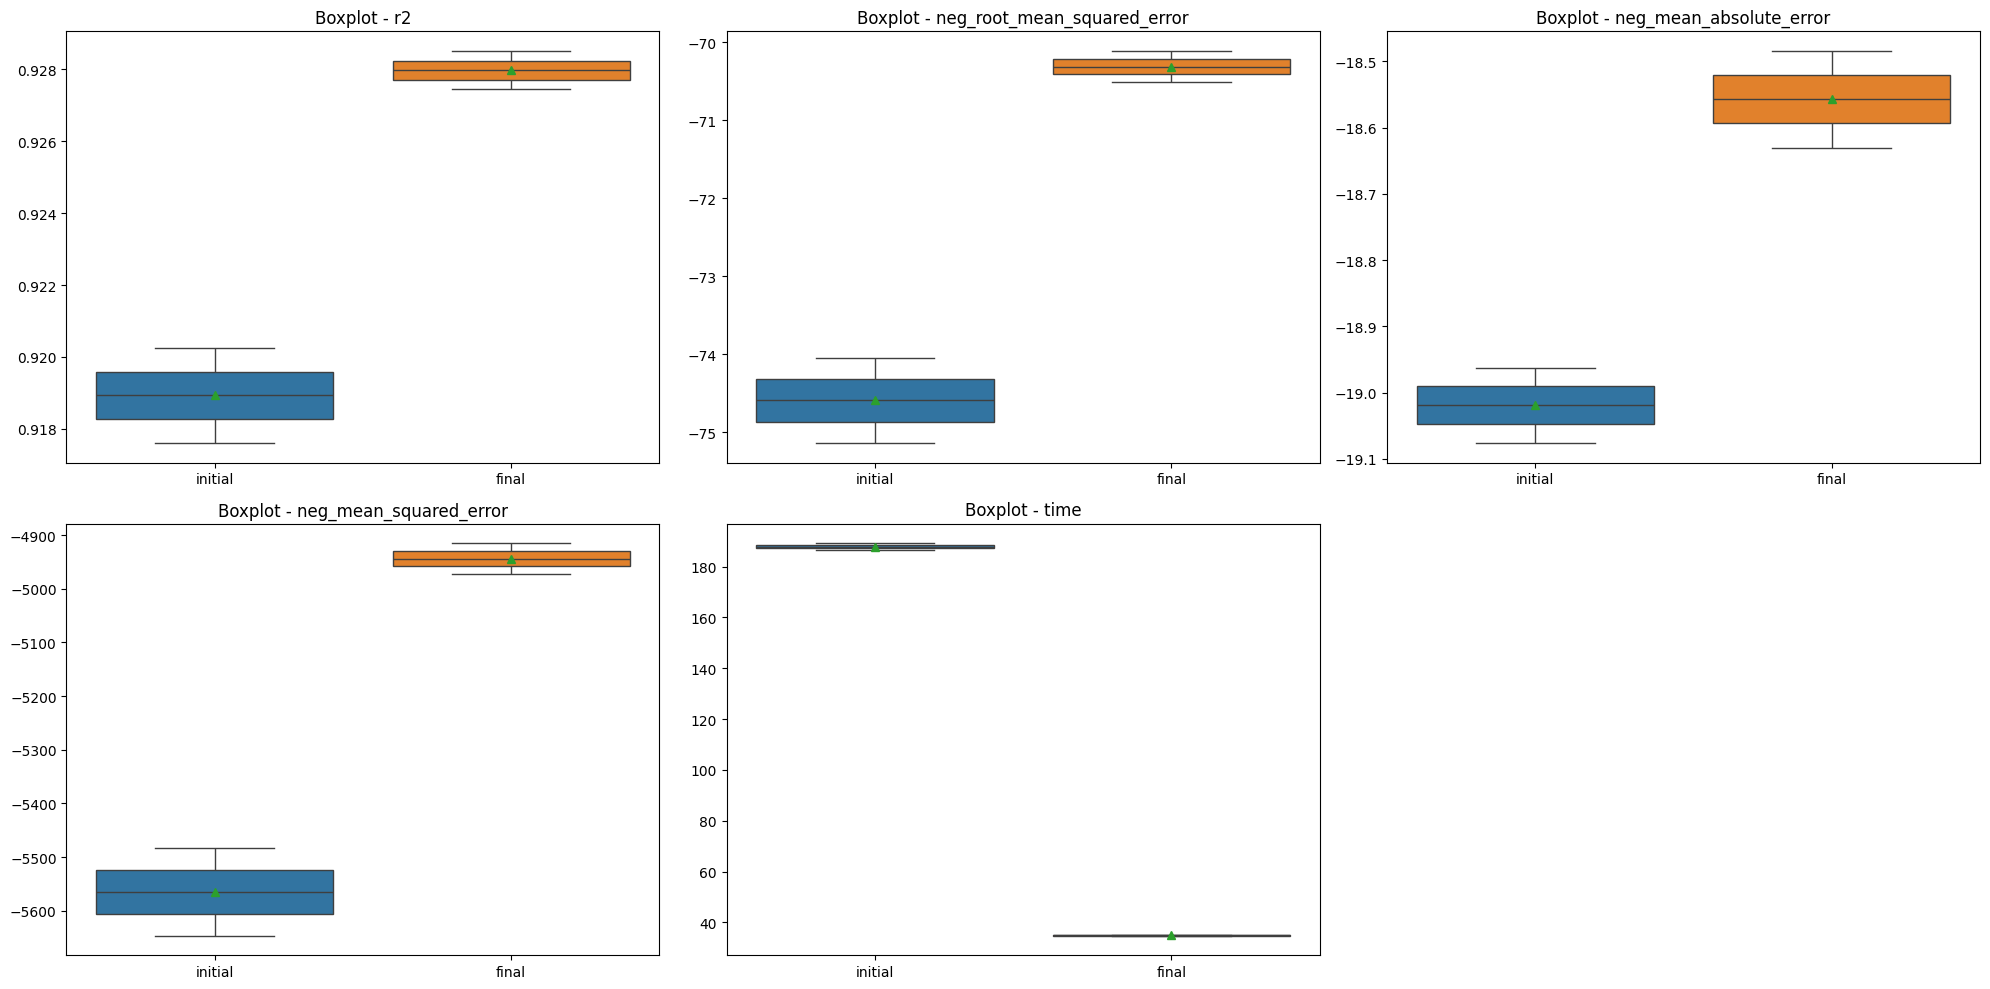

In [32]:
print('- Gráfico: Diagrama de Caixa.')

fn_charts_pandas.boxplot(df_metrics, df_metrics.columns[1:].to_list(), 'results', 'results')

plt.savefig(f'../images/outputs/charts/pandas/nb08_boxplot_models.png', format = 'png', dpi = 75, bbox_inches = 'tight', transparent = True)

plt.show()

## 07.7. Exportação do modelo otimizado

### 07.7.1. Salvando o grid search completo para auditoria e reprodutibilidade

In [33]:
joblib.dump(grid_search, consts.GRID_SEARCH_REGRESSION_PANDAS_JOBLIB)

['../models/grid_search_regression_pandas.joblib']

### 07.7.2. Salvando o modelo final treinado com os melhores parâmetros encontrados pelo Grid Search nos formatos joblib e pkl

In [34]:
joblib.dump(pipeline_final, consts.MODEL_REGRESSION_PANDAS_JOBLIB)

['../models/model_regression_pandas.joblib']

In [35]:
joblib.dump(pipeline_final, consts.MODEL_REGRESSION_PANDAS_PKL)

['../models/model_regression_pandas.pkl']